# Result 2: Algorithm 1 vs Algorithm 2 Stability Comparison

Using the trained EMA models from Result 1, we compare **Algorithm 1** (naive sampling) against **Algorithm 2**

- **(a) Visual comparison** — side-by-side outputs of both algorithms alongside the original and degraded images.
- **(b) Metrics comparison** — FID / SSIM / RMSE for Alg 1 vs Alg 2 on each dataset.
- **(c) Intermediate step visualization** — images at several steps of the reverse process, plus a quantitative drift curve measuring deviation from the ideal trajectory.


In [1]:
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount("/content/drive")
repo= "/content/drive/MyDrive/cs4782-final-project"
%cd {repo}

Mounted at /content/drive
/content/drive/MyDrive/cs4782-final-project


In [2]:
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount("/content/drive")
repo= "/content/drive/MyDrive/cs4782-final-project"
%cd {repo}
!pip install -q -r requirements.txt

DATASETS = {
    "mnist": dict(
        kernel_size= 11, num_timesteps=20, kernel_std= 7.0,
        blur_routine="Constant", image_channels=1,
    ),
    "cifar10": dict(
        kernel_size=11, num_timesteps=50, kernel_std=0.1,
        blur_routine= "Special6", image_channels=3,
    ),
    "celeba": dict(
        kernel_size=15, num_timesteps=200, kernel_std= 0.01,
        blur_routine="Exponential_Reflect", image_channels= 3,
    ),

}

CHECKPOINTS= {
    "mnist": "./checkpoints/mnist.pt",
    "cifar10": "./checkpoints/cifar10.pt",
    #"celeba": "./checkpoints/celeba.pt",

}

BATCH_SIZE= 16 # Reduced batch size to prevent OutOfMemoryError
N_VIS_SAMPLES        = 8
N_TRAJECTORY_SAMPLES = 4
N_TRAJECTORY_STEPS   = 6
N_DRIFT_SAMPLES      = 32

import os
RESULTS_DIR = "./results"
FIG_DIR     = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/cs4782-final-project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.8 MB/s eta 0:00:00


In [3]:
import torch
import numpy as np
import json
from data.datasets import get_loader
from src.model import build_unet
from src.degradation import Degradation
from src.evaluate import evaluate_model
from src.sampling import (
    algorithm1_sample,
    algorithm2_sample,
    sample_with_intermediates,
)

device= "cuda" if torch.cuda.is_available() else "cpu"

print("device: ", device)

def run_one(dataset_name):
    cfg= DATASETS[dataset_name]
    T = cfg["num_timesteps"]

    test_loader= get_loader(dataset_name, "test", batch_size= BATCH_SIZE, num_workers= 2, shuffle= False)
    degradation= Degradation(**cfg).to(device)
    model = build_unet(dataset_name).to(device)
    ckpt= torch.load(CHECKPOINTS[dataset_name], map_location=device)
    # use ema weights and not raw model
    model.load_state_dict(ckpt["ema"])
    model.eval()

    return evaluate_model(model, degradation, test_loader, t=T, device= device)


device:  cuda


In [4]:
from torchmetrics.image import StructuralSimilarityIndexMeasure, FrechetInceptionDistance
import src.evaluate

# Monkey-patch the compute_ssim function in src.evaluate
def _fixed_compute_ssim(image1, image2):
    global device
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    return ssim_metric(image1, image2)

src.evaluate.compute_ssim = _fixed_compute_ssim

# Monkey-patch the compute_fid function in src.evaluate
def _fixed_compute_fid(real_images, generated_images):
    global device
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_images, real=True)
    fid.update(generated_images, real=False)
    return fid.compute().item()

src.evaluate.compute_fid = _fixed_compute_fid

print("Patched src.evaluate.compute_ssim and src.evaluate.compute_fid to move metrics to the correct device.")

ImportError: cannot import name 'FrechetInceptionDistance' from 'torchmetrics.image' (/usr/local/lib/python3.12/dist-packages/torchmetrics/image/__init__.py)

In [5]:
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.5 MB/s eta 0:00:00


In [6]:
# helpers used only by the visualization cells below — cached so we don't reload
# weights for every figure. (run_one above always loads fresh, matching notebook 1.)
_MODEL_CACHE = {}

def load_model_and_degradation(dataset_name):
    if dataset_name in _MODEL_CACHE:
        return _MODEL_CACHE[dataset_name]
    cfg = DATASETS[dataset_name]
    degradation = Degradation(**cfg).to(device)
    model = build_unet(dataset_name).to(device)
    ckpt = torch.load(CHECKPOINTS[dataset_name], map_location=device)
    model.load_state_dict(ckpt["ema"])
    model.eval()
    _MODEL_CACHE[dataset_name] = (model, degradation, cfg["num_timesteps"])
    return _MODEL_CACHE[dataset_name]

def show_img(ax, t):
    """Plot a single (C, H, W) image tensor on `ax`."""
    img = t.detach().cpu().clamp(0, 1).numpy()
    if img.shape[0] == 1:
        ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    else:
        ax.imshow(img.transpose(1, 2, 0))
    ax.set_xticks([]); ax.set_yticks([])

def first_batch(dataset_name, n):
    loader = get_loader(dataset_name, "test", batch_size=n,
                        num_workers=2, shuffle=False)
    images, _ = next(iter(loader))
    return images.to(device)

 Metrics comparison — Algorithm 1 vs Algorithm 2

For each dataset we run both algorithms on the full test set and compare against the real images with FID, SSIM, and RMSE. We reuse `run_one` (which calls `evaluate_model`) and just keep the `alg1` / `alg2` entries.


In [7]:
metrics_results= {}

for i in DATASETS:
    print(f"--- {i} ---")
    full = run_one(i)
    # keep only the two methods we're comparing in this notebook
    metrics_results[i] = {"alg1": full["alg1"], "alg2": full["alg2"]}
    print(metrics_results[i])

--- mnist ---


ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.

In [ ]:
def format_stability_table(results):
    out = ["| Dataset  | Algorithm | FID    | SSIM   | RMSE   |",
           "|----------|-----------|--------|--------|--------|"]
    for ds, res in results.items():
        for method, label in [("alg1", "Alg 1"), ("alg2", "Alg 2")]:
            r= res[method]
            out.append(f"| {ds:<8} | {label:<9} | {r['fid']:6.2f} | {r['ssim']:.4f} | {r['rmse']:.4f} |")

    return "\n".join(out)

stability_table= format_stability_table(metrics_results)

print(stability_table)

## (a) Visual comparison

Four rows per dataset: **Original → Degraded → Alg 1 reconstruction → Alg 2 reconstruction**.


saved ./results/figures/stability_visual_mnist.png


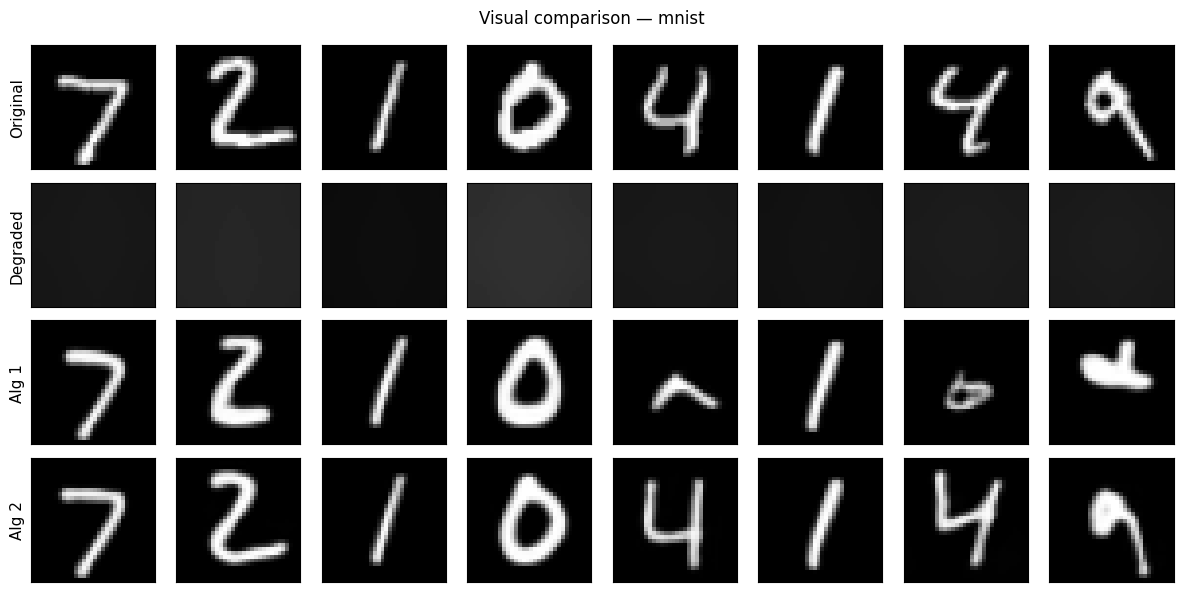

saved ./results/figures/stability_visual_cifar10.png


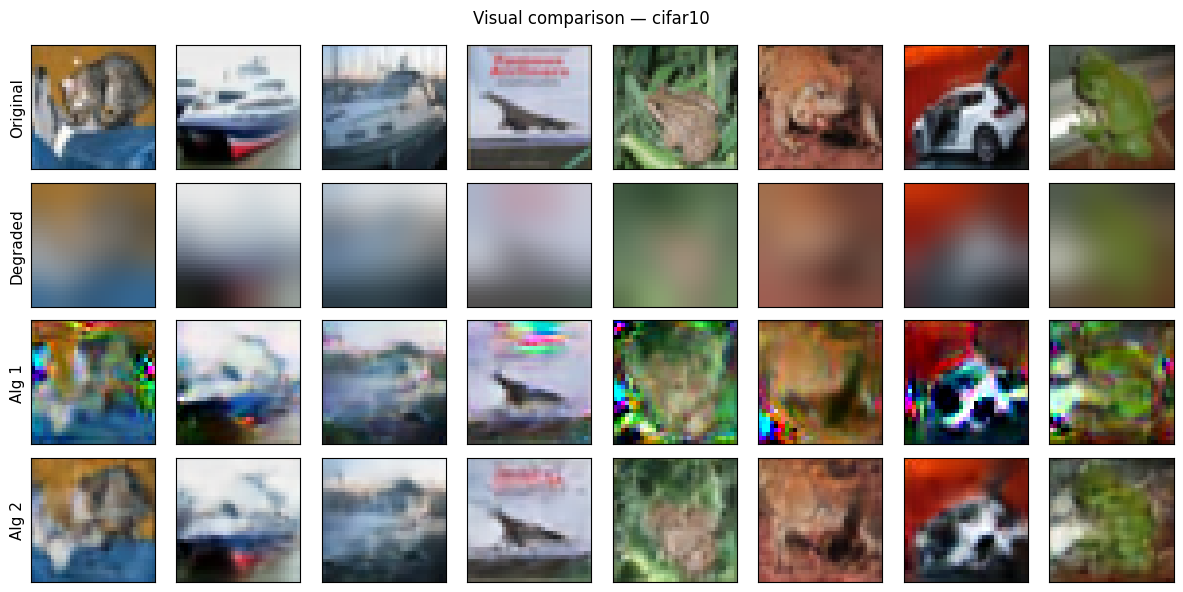

KeyError: 'celeba'

In [8]:
def make_visual_comparison(dataset_name, n_samples=N_VIS_SAMPLES, save=True):
    model, degradation, T = load_model_and_degradation(dataset_name)
    x_0 = first_batch(dataset_name, n_samples)

    with torch.no_grad():
        x_t      = degradation.forward_to_step(x_0, T)
        rec_alg1 = algorithm1_sample(model, degradation, x_t, T)
        rec_alg2 = algorithm2_sample(model, degradation, x_t, T)

    rows = [
        ("Original", x_0),
        ("Degraded", x_t),
        ("Alg 1",    rec_alg1),
        ("Alg 2",    rec_alg2),
    ]

    fig, axes = plt.subplots(len(rows), n_samples,
                             figsize=(1.5 * n_samples, 1.5 * len(rows)))
    for i, (label, imgs) in enumerate(rows):
        for j in range(n_samples):
            show_img(axes[i, j], imgs[j])
        axes[i, 0].set_ylabel(label, fontsize=11)

    fig.suptitle(f"Visual comparison — {dataset_name}")
    fig.tight_layout()
    if save:
        path = os.path.join(FIG_DIR, f"stability_visual_{dataset_name}.png")
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"saved {path}")
    plt.show()

for ds in DATASETS:
    make_visual_comparison(ds)

## (b) Intermediate step visualization

For a handful of test images we run `sample_with_intermediates` with both algorithms and spaced reverse-process steps side by side. Each column is a degradation level $s$ (from $T$ at the left down to $0$ at the right).

In [ ]:
def _save_single_image(ax_renderer, tensor_img, out_path):
    """Save one borderless PNG using the same renderer as the grid figure,
    so individual images match the combined figure visually."""
    fig, ax = plt.subplots(figsize=(2, 2))
    ax_renderer(ax, tensor_img)
    ax.set_axis_off()
    fig.savefig(out_path, dpi=200, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


def make_trajectory_figure(dataset_name,
                           n_samples=N_TRAJECTORY_SAMPLES,
                           n_steps=N_TRAJECTORY_STEPS,
                           save=True):
    model, degradation, T = load_model_and_degradation(dataset_name)
    x_0 = first_batch(dataset_name, n_samples)

    with torch.no_grad():
        x_t = degradation.forward_to_step(x_0, T)
        _, inter_alg1 = sample_with_intermediates(model, degradation, x_t, T, algorithm=1)
        _, inter_alg2 = sample_with_intermediates(model, degradation, x_t, T, algorithm=2)

    # intermediates[k] corresponds to degradation level s = T - k
    is_mnist = dataset_name.lower() == "mnist"
    if is_mnist:
        # Final-step zoom: the visual "magic" on MNIST happens in the last few steps.
        s_values = [5, 4, 3, 2, 1, 0]
        step_idxs = np.array([T - s for s in s_values])
    else:
        step_idxs = np.linspace(0, T, n_steps).astype(int)

    n_cols = len(step_idxs)

    # Per-image export folder (one per dataset) so poster assets don't collide.
    if save:
        indiv_dir = os.path.join(FIG_DIR, f"{dataset_name}_trajectory_individual")
        os.makedirs(indiv_dir, exist_ok=True)

    for img_idx in range(n_samples):
        fig, axes = plt.subplots(2, n_cols, figsize=(1.6 * n_cols, 3.4))
        for col, k in enumerate(step_idxs):
            s = T - int(k)
            img_alg1 = inter_alg1[int(k)][img_idx]
            img_alg2 = inter_alg2[int(k)][img_idx]

            show_img(axes[0, col], img_alg1)
            show_img(axes[1, col], img_alg2)
            axes[0, col].set_title(f"s={s}", fontsize=9)

            # Per-image export for the poster (all datasets).
            if save:
                fname1 = f"{dataset_name}_sample{img_idx}_alg1_s{s:02d}.png"
                fname2 = f"{dataset_name}_sample{img_idx}_alg2_s{s:02d}.png"
                _save_single_image(show_img, img_alg1,
                                   os.path.join(indiv_dir, fname1))
                _save_single_image(show_img, img_alg2,
                                   os.path.join(indiv_dir, fname2))

        axes[0, 0].set_ylabel("Alg 1", fontsize=11)
        axes[1, 0].set_ylabel("Alg 2", fontsize=11)
        fig.suptitle(f"Sampling trajectory — {dataset_name} (sample {img_idx})")
        fig.tight_layout()
        if save:
            path = os.path.join(
                FIG_DIR, f"stability_trajectory_{dataset_name}_{img_idx}.png"
            )
            fig.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()


for ds in DATASETS:
    make_trajectory_figure(ds)

### Quantitative drift curve

At each reverse step the sampler produces $x_s$. If the sampler were perfect, $x_s$ would equal $D_s(x_0^{\mathrm{real}})$, the forward degradation of the true clean image at level $s$. We measure the per-step RMSE between the sampler's $x_s$ and this ideal reference.


KeyError: 'celeba'

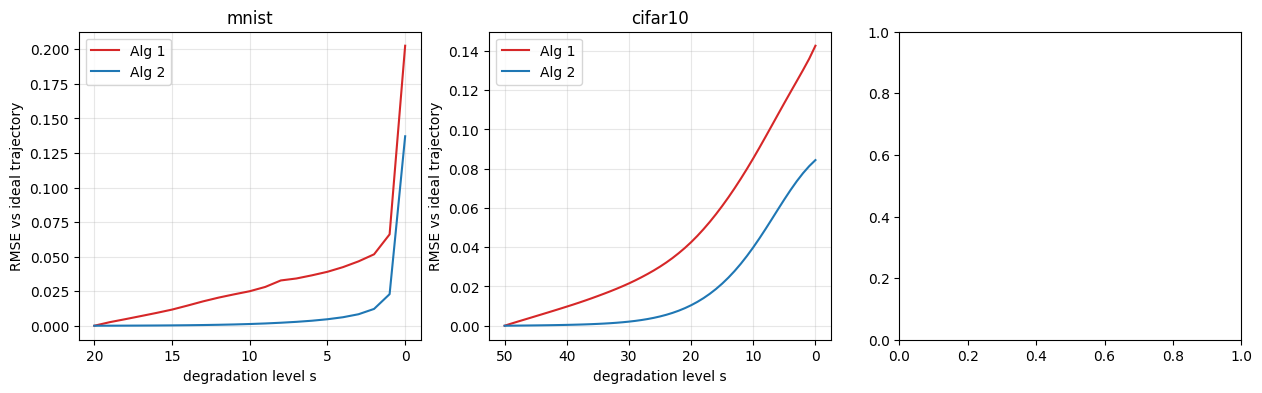

In [9]:
def compute_drift_curves(dataset_name, n_samples=N_DRIFT_SAMPLES):
    model, degradation, T = load_model_and_degradation(dataset_name)
    x_0 = first_batch(dataset_name, n_samples)

    with torch.no_grad():
        x_t = degradation.forward_to_step(x_0, T)
        _, inter_alg1 = sample_with_intermediates(model, degradation, x_t, T, algorithm=1)
        _, inter_alg2 = sample_with_intermediates(model, degradation, x_t, T, algorithm=2)

    drift_alg1, drift_alg2 = [], []
    with torch.no_grad():
        for k in range(len(inter_alg1)):
            s = T - k
            ideal = degradation.forward_to_step(x_0, s) if s > 0 else x_0
            d1 = (inter_alg1[k] - ideal).pow(2).mean(dim=(1, 2, 3)).sqrt().mean().item()
            d2 = (inter_alg2[k] - ideal).pow(2).mean(dim=(1, 2, 3)).sqrt().mean().item()
            drift_alg1.append(d1)
            drift_alg2.append(d2)
    return drift_alg1, drift_alg2, T


def _plot_drift_on_ax(ax, d1, d2, T, dataset_name):
    """Render a single drift curve onto an existing Axes — same styling
    as in the combined figure so individual exports match visually."""
    x_axis = [T - k for k in range(len(d1))]   # plot against degradation level s
    ax.plot(x_axis, d1, label="Alg 1", color="tab:red")
    ax.plot(x_axis, d2, label="Alg 2", color="tab:blue")
    ax.invert_xaxis()                           # reverse process goes T -> 0
    ax.set_xlabel("degradation level s")
    ax.set_ylabel("RMSE vs ideal trajectory")
    ax.set_title(dataset_name)
    ax.legend()
    ax.grid(alpha=0.3)


drift_curves = {}
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4), squeeze=False)
for col, ds in enumerate(DATASETS):
    d1, d2, T = compute_drift_curves(ds)
    drift_curves[ds] = {"alg1": d1, "alg2": d2, "T": T}

    # Combined figure column
    _plot_drift_on_ax(axes[0, col], d1, d2, T, ds)

    # Per-dataset individual export — same folder pattern as the trajectory exports
    indiv_dir = os.path.join(FIG_DIR, f"{ds}_drift_individual")
    os.makedirs(indiv_dir, exist_ok=True)

    fig_i, ax_i = plt.subplots(figsize=(5, 4))
    _plot_drift_on_ax(ax_i, d1, d2, T, ds)
    fig_i.tight_layout()
    fig_i.savefig(os.path.join(indiv_dir, f"{ds}_drift_curve.png"),
                  dpi=200, bbox_inches="tight")
    plt.close(fig_i)

fig.suptitle("Sampling drift: deviation from the ideal trajectory")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "stability_drift_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Save artifacts


In [ ]:
import json, os

os.makedirs("./results", exist_ok= True)

#with open(os.path.join(RESULTS_DIR, "stability_metrics.json"), "w") as f:
   # json.dump(metrics_results, f, indent= 2)

with open(os.path.join(RESULTS_DIR, "stability_table.md"), "w") as f:
    f.write(stability_table)

with open(os.path.join(RESULTS_DIR, "stability_drift_curves.json"), "w") as f:
    json.dump(
        {k: {"alg1": v["alg1"], "alg2": v["alg2"], "T": v["T"]}
         for k, v in drift_curves.items()},
        f, indent= 2,
    )

print(f"saved to {RESULTS_DIR}")